示例文件已创建：stock_data.xlsx


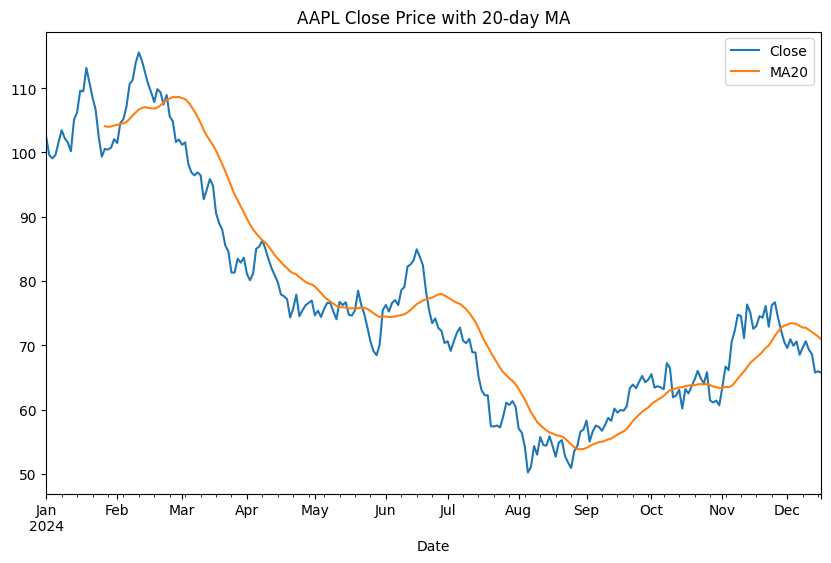

In [40]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
# 生成模拟数据
dates = pd.date_range('2024-01-01', periods=252, freq='B')
df = pd.DataFrame({
    'Date': dates,
    'Close': 100 + np.cumsum(np.random.randn(252) * 2),
    'Volume': np.random.randint(1e6, 1e7, 252),
    'High': 100 + np.cumsum(np.random.randn(252) * 2) + np.random.uniform(0, 5, 252),
    'Low': 100 + np.cumsum(np.random.randn(252) * 2) - np.random.uniform(0, 5, 252)
})
# 保存为 Excel
df.to_excel('stock_data.xlsx', index=False)
print("示例文件已创建：stock_data.xlsx")
df = pd.read_excel('stock_data.xlsx')
#对读取的 df：将 Date 列设为索引,检查缺失值,如有缺失，用 ffill 填充
df.set_index('Date', inplace = True)
df.isna().sum()
df = df.ffill()
#任务 3：计算指标: 日收益率(return),20 日滚动均值(MA20),20 日滚动波动率（年化）
df['return'] = df['Close'] / df['Close'].shift(1) -1
df['MA20'] = df['Close'].rolling(window = 20).mean()
df['vol_20_yr'] = df['return'].rolling( window = 20).std() * np.sqrt(252)
#任务 4：保存结果到 Excel
df.to_excel('stock_analysis.xlsx',index =False)
#任务5: 简单画图
#画收盘价和MA20
df[['Close','MA20']].plot(figsize=(10,6))
plt.title('AAPL Close Price with 20-day MA')
plt.show()

In [26]:
os.getcwd()

'C:\\Users\\hjx06'